In [3]:
!python -m pip install numpy pandas \
    qiskit-aer qiskit-algorithms qiskit-machine-learning qiskit-ibm-runtime \
    pylatexenc ucimlrepo \
    xgboost catboost seaborn libsvm-official \
    jinja2 \
    scikit-optimize


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sys
import os

cwd = os.path.abspath(os.getcwd())
project_root = cwd.split("codes")[0] + "codes"

sys.path.append(os.path.abspath(project_root))

from utils.prepare_data import prepare_data

In [5]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [6]:
import warnings
from qiskit.transpiler import generate_preset_pass_manager
warnings.filterwarnings('ignore')

In [7]:
import sys
import importlib

def reload_package(package_name):
    modules_to_reload = [
        name for name in sys.modules
        if name.startswith(package_name)
    ]

    for name in sorted(modules_to_reload, reverse=True):
        importlib.reload(sys.modules[name])

# Usage
reload_package("model")
reload_package("utils")

In [8]:
dataset_path = os.path.join(project_root, "dataset", "Dataset_TehHijau.csv")
feature_cols = [
        "MQ3", 
        "TGS822", 
        "TGS2602", 
        "MQ5", 
        "MQ138", 
        "TGS2620", 
        "TGS813", 
        "TGS2600", 
        "TGS2611", 
        "TGS2603",
        "Humidity",
        "Celsius",
    ]
target_cols = "Kategori"

quantum_kernel_types = [
    # 'full', 
    'linear', 
    # 'circular', 
    # 'pauli_x', 
    # 'pauli_y', 
    # 'pauli_z'
]
kernel_types = [
    'linear', 
    # 'poly', 
    # 'rbf', 
    # 'sigmoid'
]

In [9]:
import pandas as pd
data = pd.read_csv(dataset_path)
data.head(10)

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Chop_ID,Sampling_ID,Aroma,Taste,Color,Appearance,Dreg,Kategori,Standar Kualitas,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
0,90.0,43.0,46.0,133.0,97.0,46.0,552.0,289.0,546.0,371.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
1,90.0,42.0,47.0,133.0,96.0,47.0,551.0,290.0,547.0,371.0,46.5,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
2,89.0,42.0,47.0,133.0,97.0,45.0,553.0,291.0,547.0,369.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
3,89.0,41.0,47.0,133.0,96.0,45.0,552.0,290.0,546.0,370.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.4

In [10]:
data.describe()

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Aroma,Taste,Color,Appearance,Dreg,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
count,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,1.040900e+04,1.040900e+04,1.040900e+04,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,10409.0,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000
mean,89.414833,47.600730,47.936209,98.291575,89.182246,51.548756,533.670093,213.738592,531.124604,330.500336,48.387732,39.656701,2.935143,34.888942,3.035383,3.135306,3.071880,89.401187,88.072610,90.838121,0.983066,0.031130,-0.497871,797.282995,51.381383,46.428283,86.377366,12.767992,0.047886,-0.767730,461.091603,48.923492,46.665674,56.401095,3.417439,0.042129,-0.742829,435.501633,98.319587,97.190220,99.975002,0.977440,0.153864,-0.336209,872.003728,89.167083,87.839082,90.566625,0.975194,0.054069,-0.778237,790.103132,52.047207,50.200692,56.931309,2.411880,0.011063,-0.779548,460.377366,533.585382,530.475646,535.648189,1.716062,-0.230519,-0.613955,4754.938419,215.542657,212.039427,231.564223,6.549817,-0.059306,-0.657508,1919.990364,531.039823,529.310693,532.089442,1.000540,-0.031123,-0.890127,4742.842444,330.447166,328.831396,331.640503,0.980595,0.022313,-0.777011,2953.280046,4.077809e+03,48.175252,4.034278e+04,1.274229e+04,-2.069636e-02,-0.

Text(0.5, 1.0, 'Histogram for the Kategori')

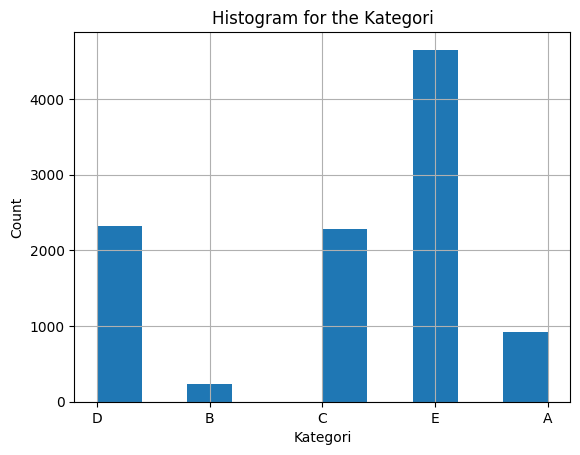

In [11]:
import matplotlib.pyplot as plt
data['Kategori'].hist()
plt.xlabel('Kategori')
plt.ylabel('Count')
plt.title('Histogram for the Kategori')

In [12]:
X = data[feature_cols]
y = data[target_cols]

print(X.shape, y.shape)

(10409, 12) (10409,)


In [13]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [14]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
def plot_pca_variance(X, n_components, threshold=0.95):
  pca = PCA(n_components=n_components)
  pca.fit(X)

  cumvar = np.cumsum(pca.explained_variance_ratio_)
  n_optimal = np.argmax(cumvar >= threshold) + 1

  plt.figure(figsize=(8, 5))
  plt.plot(range(1, n_components + 1), cumvar, marker='o', color='blue')
  plt.axhline(y=threshold, color='gray', linestyle='--', linewidth=1)
  plt.xlabel('Number of Principal Components')
  plt.ylabel('Cumulative Explained Variance')
  plt.xticks(range(1, n_components + 1))
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  print(f'Optimal number of components to retain {threshold*100:.0f}% variance: {n_optimal}')

  return n_optimal

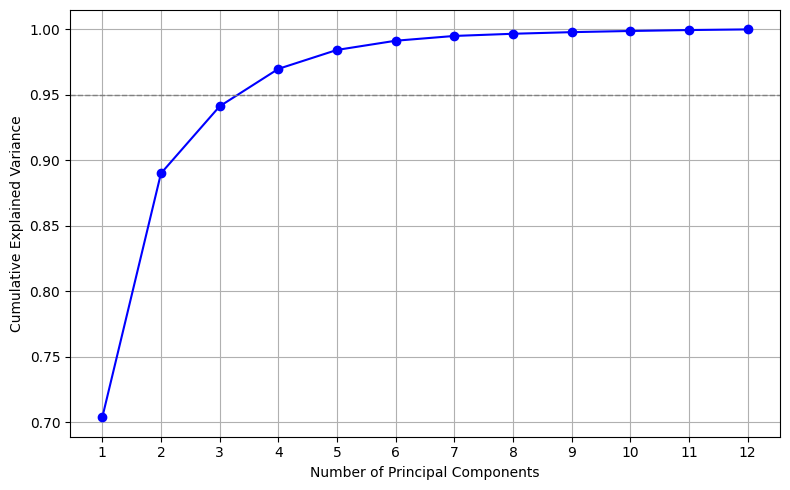

Optimal number of components to retain 95% variance: 4


In [15]:
n_optimal = plot_pca_variance(X, n_components=X.shape[1], threshold=0.95)

In [16]:
import time
from pathlib import Path
from datetime import datetime

all_best = []  # collects best_result from every model
_iter_t0 = None

# Logger setup
log_dir = Path("./results/logs/ml/best_param")
log_dir.mkdir(parents=True, exist_ok=True)

_current_log_path = None

def setup_logger(name):
  """Panggil di awal tiap section. name contoh: 'svc_linear', 'xgb_gbtree'."""
  global _current_log_path
  _current_log_path = log_dir / f"classical_{name}_hpo.log"
  # truncate file kalau sudah ada, biar tiap run fresh
  _current_log_path.write_text("")
  log(f"📝 Log: {_current_log_path}")
  log(f"🕒 Started: {datetime.now().isoformat(timespec='seconds')}")

def log(msg=""):
  """Print ke console dan append ke file log section aktif."""
  print(msg)
  if _current_log_path is not None:
    with open(_current_log_path, "a", encoding="utf-8") as f:
      f.write(str(msg) + "\n")


# 1. SVC

## 1.1 Linear

In [17]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [10],
  'tol': [0.1]
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [18]:
setup_logger("svc_linear")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from utils.hpo import get_search_space
from skopt import BayesSearchCV
from sklearn.decomposition import PCA
from model.models import svc_model
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', SVC(class_weight='balanced',
        kernel='linear',
        probability=True,
        random_state=42, 
        decision_function_shape='ovr',
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'y_true': list(y_val_all),
        'y_pred': list(y_pred_all),
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\ml\best_param\classical_svc_linear_hpo.log
🕒 Started: 2026-06-06T20:49:03
🔬 Search space: 1 C × 1 tol =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] C=10 | tol=0.1
    F1 → Acc=0.3934 | Prec=0.5784 | Rec=0.3934 | F1=0.4058 | AUROC=0.6947 | PRAUC=0.4846
    F2 → Acc=0.4025 | Prec=0.5790 | Rec=0.4025 | F1=0.4163 | AUROC=0.7087 | PRAUC=0.4999
    F3 → Acc=0.3838 | Prec=0.5537 | Rec=0.3838 | F1=0.3918 | AUROC=0.6798 | PRAUC=0.4719
    F4 → Acc=0.4049 | Prec=0.5599 | Rec=0.4049 | F1=0.4117 | AUROC=0.6925 | PRAUC=0.4837
    F5 → Acc=0.3767 | Prec=0.5466 | Rec=0.3767 | F1=0.3835 | AUROC=0.6853 | PRAUC=0.4723
  ✅  Acc:0.3923±0.0108 | Precision:0.5635±0.0131  |Recall:0.3923±0.0108 |F1:0.4018±0.0123 | AUROC:0.6922±0.0098 | PRAUC:0.4825±0.0103 | MCC:0.2574 | Composite:0.5223

🏆 Best config : C=10 | tol=0.1
   Composite   : 0.5223 (AUROC=0.6922±0.0098 | PRAUC=0.4825±0.0103 | Acc=0.3923±0.0108 |Prec=0.5635±0.0131 |Rec=0.3923±0.010

In [19]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "svc_linear_hpo.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/svc_linear_hpo.csv


In [20]:
# ── Collect best result ──
best_result['model'] = "SVC Linear"
all_best.append(dict(best_result))
log(f"✅ [SVC Linear] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [SVC Linear] recorded | Exec. time: 200.6s


## 1.2 Poly

In [21]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [1],
  'tol': [0.1],
  'degree': [5],
  'gamma': [0.5],
  'coef0': [3],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [22]:
setup_logger("svc_poly")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from utils.hpo import get_search_space
from skopt import BayesSearchCV
from sklearn.decomposition import PCA
from model.models import svc_model
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', SVC(class_weight='balanced',kernel='poly', probability=True, random_state=42, **params))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

     
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'y_true': list(y_val_all),
        'y_pred': list(y_pred_all),
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\ml\best_param\classical_svc_poly_hpo.log
🕒 Started: 2026-06-06T20:52:25
🔬 Search space: 1 C × 1 tol × 1 degree × 1 gamma × 1 coef0 =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] C=1 | tol=0.1 | degree=5 | gamma=0.5 | coef0=3
    F1 → Acc=0.9693 | Prec=0.9708 | Rec=0.9693 | F1=0.9696 | AUROC=0.9987 | PRAUC=0.9958
    F2 → Acc=0.9726 | Prec=0.9732 | Rec=0.9726 | F1=0.9727 | AUROC=0.9982 | PRAUC=0.9951
    F3 → Acc=0.9664 | Prec=0.9680 | Rec=0.9664 | F1=0.9667 | AUROC=0.9976 | PRAUC=0.9938
    F4 → Acc=0.9721 | Prec=0.9733 | Rec=0.9721 | F1=0.9724 | AUROC=0.9988 | PRAUC=0.9962
    F5 → Acc=0.9635 | Prec=0.9651 | Rec=0.9635 | F1=0.9637 | AUROC=0.9981 | PRAUC=0.9935
  ✅  Acc:0.9688±0.0035 | Precision:0.9701±0.0032  |Recall:0.9688±0.0035 |F1:0.9691±0.0034 | AUROC:0.9983±0.0004 | PRAUC:0.9949±0.0011 | MCC:0.9555 | Composite:0.9873

🏆 Best config : C=1 | tol=0.1 | degree=5 | gamma=0.5 | coef0=3
   Composite   : 0.9873 (AUROC=

In [23]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "svc_poly_hpo.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/svc_poly_hpo.csv


In [24]:
# ── Collect best result ──
best_result['model'] = "SVC Poly"
all_best.append(dict(best_result))
log(f"✅ [SVC Poly] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [SVC Poly] recorded | Exec. time: 65.9s


## 1.3 RBF

In [25]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [10],
  'tol': [0.1],
  'gamma': [0.5],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [26]:
setup_logger("svc_rbf")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from utils.hpo import get_search_space
from skopt import BayesSearchCV
from sklearn.decomposition import PCA
from model.models import svc_model
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  
  log(f"\n  ▶ {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', SVC(class_weight='balanced', decision_function_shape='ovr', kernel='rbf', probability=True, random_state=42, **params))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

     
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'y_true': list(y_val_all),
        'y_pred': list(y_pred_all),
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\ml\best_param\classical_svc_rbf_hpo.log
🕒 Started: 2026-06-06T20:53:31
🔬 Search space: 1 C × 1 tol × 1 gamma =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] C=10 | tol=0.1 | gamma=0.5

  ▶ C=10 | tol=0.1 | gamma=0.5
    F1 → Acc=0.9726 | Prec=0.9740 | Rec=0.9726 | F1=0.9729 | AUROC=0.9991 | PRAUC=0.9968
    F2 → Acc=0.9745 | Prec=0.9753 | Rec=0.9745 | F1=0.9747 | AUROC=0.9975 | PRAUC=0.9895
    F3 → Acc=0.9721 | Prec=0.9736 | Rec=0.9721 | F1=0.9725 | AUROC=0.9976 | PRAUC=0.9928
    F4 → Acc=0.9765 | Prec=0.9773 | Rec=0.9765 | F1=0.9767 | AUROC=0.9990 | PRAUC=0.9965
    F5 → Acc=0.9649 | Prec=0.9666 | Rec=0.9649 | F1=0.9653 | AUROC=0.9981 | PRAUC=0.9935
  ✅  Acc:0.9721±0.0039 | Precision:0.9733±0.0036  |Recall:0.9721±0.0039 |F1:0.9724±0.0038 | AUROC:0.9983±0.0007 | PRAUC:0.9938±0.0027 | MCC:0.9603 | Composite:0.9881

🏆 Best config : C=10 | tol=0.1 | gamma=0.5
   Composite   : 0.9881 (AUROC=0.9983±0.0007 | PRAUC=0.9938±0

In [27]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "svc_rbf_hpo.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/svc_rbf_hpo.csv


In [28]:
# ── Collect best result ──
best_result['model'] = "SVC RBF"
all_best.append(dict(best_result))
log(f"✅ [SVC RBF] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [SVC RBF] recorded | Exec. time: 11.3s


## 1.4 Sigmoid

In [29]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [1],
  'tol': [0.1],
  'gamma': [0.01],
  'coef0': [0],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [30]:
setup_logger("svc_sigmoid")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from utils.hpo import get_search_space
from skopt import BayesSearchCV
from sklearn.decomposition import PCA
from model.models import svc_model
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  
  log(f"\n  ▶ {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', SVC(decision_function_shape='ovr', class_weight='balanced',kernel='sigmoid', probability=True, random_state=42, **params))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

     
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'y_true': list(y_val_all),
        'y_pred': list(y_pred_all),
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\ml\best_param\classical_svc_sigmoid_hpo.log
🕒 Started: 2026-06-06T20:53:42
🔬 Search space: 1 C × 1 tol × 1 gamma × 1 coef0 =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] C=1 | tol=0.1 | gamma=0.01 | coef0=0

  ▶ C=1 | tol=0.1 | gamma=0.01 | coef0=0
    F1 → Acc=0.3497 | Prec=0.5191 | Rec=0.3497 | F1=0.3541 | AUROC=0.6785 | PRAUC=0.4542
    F2 → Acc=0.3598 | Prec=0.5453 | Rec=0.3598 | F1=0.3712 | AUROC=0.6922 | PRAUC=0.4695
    F3 → Acc=0.3463 | Prec=0.5239 | Rec=0.3463 | F1=0.3522 | AUROC=0.6632 | PRAUC=0.4432
    F4 → Acc=0.3871 | Prec=0.5411 | Rec=0.3871 | F1=0.3851 | AUROC=0.6791 | PRAUC=0.4595
    F5 → Acc=0.3489 | Prec=0.5132 | Rec=0.3489 | F1=0.3498 | AUROC=0.6699 | PRAUC=0.4439
  ✅  Acc:0.3583±0.0151 | Precision:0.5285±0.0125  |Recall:0.3583±0.0151 |F1:0.3625±0.0136 | AUROC:0.6766±0.0098 | PRAUC:0.4541±0.0099 | MCC:0.2135 | Composite:0.4963

🏆 Best config : C=1 | tol=0.1 | gamma=0.01 | coef0=0
   Composite   : 

In [31]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "svc_rbf_hpo.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/svc_rbf_hpo.csv


In [32]:
# ── Collect best result ──
best_result['model'] = "SVC Sigmoid"
all_best.append(dict(best_result))
log(f"✅ [SVC Sigmoid] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [SVC Sigmoid] recorded | Exec. time: 96.7s


# 2. XGBoost

## 2.1 GBTree

In [33]:
# Search Space Configuration
import numpy as np

# search_space = {
#   'n_estimators': [1000],
#   'learning_rate': [0.01],
#   'max_depth': [10],
#   'subsample': [0.5],
#   'colsample_bytree': [1],
# }

search_space = {
  'n_estimators': [100],
  'learning_rate': [0.1],
  'max_depth': [10],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [34]:
setup_logger("xgb_gbtree")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_sample_weight  # ← imbalance handling
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  
  log(f"\n  ▶ {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('xgb', XGBClassifier(
        booster='gbtree', objective='multi:softprob', random_state=42, device='cuda', **params
      ))
    ])

    # Per-fold balanced sample_weight (XGBoost tidak punya class_weight)
    sw_train = compute_sample_weight('balanced', y_train)
    model.fit(X_train, y_train, xgb__sample_weight=sw_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'y_true': list(y_val_all),
        'y_pred': list(y_pred_all),
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\ml\best_param\classical_xgb_gbtree_hpo.log
🕒 Started: 2026-06-06T20:55:19
🔬 Search space: 1 n_estimators × 1 learning_rate × 1 max_depth =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] n_estimators=100 | learning_rate=0.1 | max_depth=10

  ▶ n_estimators=100 | learning_rate=0.1 | max_depth=10
    F1 → Acc=0.9673 | Prec=0.9677 | Rec=0.9673 | F1=0.9674 | AUROC=0.9989 | PRAUC=0.9965
    F2 → Acc=0.9750 | Prec=0.9753 | Rec=0.9750 | F1=0.9751 | AUROC=0.9990 | PRAUC=0.9973
    F3 → Acc=0.9673 | Prec=0.9676 | Rec=0.9673 | F1=0.9674 | AUROC=0.9981 | PRAUC=0.9935
    F4 → Acc=0.9779 | Prec=0.9782 | Rec=0.9779 | F1=0.9780 | AUROC=0.9993 | PRAUC=0.9978
    F5 → Acc=0.9644 | Prec=0.9648 | Rec=0.9644 | F1=0.9645 | AUROC=0.9978 | PRAUC=0.9926
  ✅  Acc:0.9704±0.0051 | Precision:0.9707±0.0051  |Recall:0.9704±0.0051 |F1:0.9705±0.0051 | AUROC:0.9986±0.0006 | PRAUC:0.9955±0.0021 | MCC:0.9575 | Composite:0.9882

🏆 Best config : n_estimato

In [35]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "xgb_gbtree_hpo.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/xgb_gbtree_hpo.csv


In [36]:
# ── Collect best result ──
best_result['model'] = "XGBoost GBTree"
all_best.append(dict(best_result))
log(f"✅ [XGBoost GBTree] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [XGBoost GBTree] recorded | Exec. time: 13.2s


## 2.2 Dart

In [37]:
# Search Space Configuration
import numpy as np

# search_space = {
#   'n_estimators': [1000],
#   'learning_rate': [0.01],
#   'max_depth': [10],
#   'subsample': [0.5],
#   'colsample_bytree': [1],

#   'rate_drop': [0],
# }

search_space = {
  'n_estimators': [100],
  'learning_rate': [0.1],
  'max_depth': [10],
  'rate_drop': [0.1],
  'skip_drop': [0.5],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [38]:
setup_logger("xgb_dart")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_sample_weight  # ← imbalance handling
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  
  log(f"\n  ▶ {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('xgb', XGBClassifier(
        booster='dart', objective='multi:softprob', random_state=42, device='cuda', **params
      ))
    ])

    # Per-fold balanced sample_weight (XGBoost tidak punya class_weight)
    sw_train = compute_sample_weight('balanced', y_train)
    model.fit(X_train, y_train, xgb__sample_weight=sw_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'y_true': list(y_val_all),
        'y_pred': list(y_pred_all),
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\ml\best_param\classical_xgb_dart_hpo.log
🕒 Started: 2026-06-06T20:55:32
🔬 Search space: 1 n_estimators × 1 learning_rate × 1 max_depth × 1 rate_drop × 1 skip_drop =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] n_estimators=100 | learning_rate=0.1 | max_depth=10 | rate_drop=0.1 | skip_drop=0.5

  ▶ n_estimators=100 | learning_rate=0.1 | max_depth=10 | rate_drop=0.1 | skip_drop=0.5
    F1 → Acc=0.9640 | Prec=0.9644 | Rec=0.9640 | F1=0.9641 | AUROC=0.9987 | PRAUC=0.9959
    F2 → Acc=0.9702 | Prec=0.9708 | Rec=0.9702 | F1=0.9703 | AUROC=0.9989 | PRAUC=0.9969
    F3 → Acc=0.9621 | Prec=0.9629 | Rec=0.9621 | F1=0.9623 | AUROC=0.9976 | PRAUC=0.9921
    F4 → Acc=0.9779 | Prec=0.9783 | Rec=0.9779 | F1=0.9780 | AUROC=0.9992 | PRAUC=0.9975
    F5 → Acc=0.9620 | Prec=0.9625 | Rec=0.9620 | F1=0.9621 | AUROC=0.9971 | PRAUC=0.9906
  ✅  Acc:0.9672±0.0061 | Precision:0.9678±0.0060  |Recall:0.9672±0.0061 |F1:0.9674±0.0061 | AUROC:0.998

In [39]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "xgb_dart_hpo.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/xgb_dart_hpo.csv


In [40]:
# ── Collect best result ──
best_result['model'] = "XGBoost Dart"
all_best.append(dict(best_result))
log(f"✅ [XGBoost Dart] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [XGBoost Dart] recorded | Exec. time: 25.5s


# 3. CatBoost

In [41]:
# Search Space Configuration
import numpy as np

search_space = {
  'iterations': [500],
  'depth': [10],
  'learning_rate': [0.1],
  'l2_leaf_reg': [1],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [42]:
setup_logger("catboost")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)
from catboost import CatBoostClassifier

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('cat', CatBoostClassifier(
        loss_function="MultiClassOneVsAll",
        eval_metric="Accuracy",
        verbose=0,
        random_seed=42, 
        task_type="GPU",
        devices='0',
        auto_class_weights='Balanced',  # ← imbalance handling
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)
    y_prob = y_prob / y_prob.sum(axis=1, keepdims=True)  # Normalize probabilities

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'y_true': list(y_val_all),
        'y_pred': list(y_pred_all),
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\ml\best_param\classical_catboost_hpo.log
🕒 Started: 2026-06-06T20:55:58
🔬 Search space: 1 iterations × 1 depth × 1 learning_rate × 1 l2_leaf_reg =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/1] iterations=500 | depth=10 | learning_rate=0.1 | l2_leaf_reg=1
    F1 → Acc=0.9784 | Prec=0.9789 | Rec=0.9784 | F1=0.9785 | AUROC=0.9993 | PRAUC=0.9978
    F2 → Acc=0.9789 | Prec=0.9792 | Rec=0.9789 | F1=0.9789 | AUROC=0.9993 | PRAUC=0.9980
    F3 → Acc=0.9726 | Prec=0.9730 | Rec=0.9726 | F1=0.9728 | AUROC=0.9989 | PRAUC=0.9965
    F4 → Acc=0.9813 | Prec=0.9815 | Rec=0.9813 | F1=0.9813 | AUROC=0.9996 | PRAUC=0.9985
    F5 → Acc=0.9664 | Prec=0.9668 | Rec=0.9664 | F1=0.9665 | AUROC=0.9985 | PRAUC=0.9951
  ✅  Acc:0.9755±0.0054 | Precision:0.9759±0.0053  |Recall:0.9755±0.0054 |F1:0.9756±0.0054 | AUROC:0.9991±0.0004 | PRAUC:0.9972±0.0013 | MCC:0.9649 | Composite:0.9906

🏆 Best config : iterations=500 | depth=10 | learning_rate=0.1 | l

In [43]:
import pandas as pd
import os

dirpath = "./results/best_param/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "catboost_hpo.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")

✅ Saved: ./results/best_param/catboost_hpo.csv


In [44]:
# ── Collect best result ──
best_result['model'] = "CatBoost"
all_best.append(dict(best_result))
log(f"✅ [CatBoost] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [CatBoost] recorded | Exec. time: 73.9s


---
## 📊 Tabel Evaluasi Akhir

In [45]:
# ════════════════════════════════════════════════════════════
# 📊 TABEL EVALUASI AKHIR – Classical Models
# ════════════════════════════════════════════════════════════
import pandas as pd

def build_eval_table(all_best):
    rows = []
    for r in all_best:
        params_str = ' | '.join(f'{k}={v}' for k, v in r.get('params', {}).items())
        rows.append({
            'Model'          : r['model'],
            'Accuracy'       : r['acc'],
            'Precision'      : r['prec'],
            'Recall'         : r['rec'],
            'F1-Score'       : r['f1'],
            'ROC-AUC'        : r['roc'],
            'PR-AUC'         : r['pra'],
            'Exec. Time (s)' : round(r['execution_time'], 2) if 'execution_time' in r else 'N/A',
            'Best Params'    : params_str,
        })
    df = pd.DataFrame(rows)
    df = df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
    df.index += 1
    return df

pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.4f}'.format)

eval_df = build_eval_table(all_best)
display(eval_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Exec. Time (s),Best Params
1,CatBoost,0.9755±0.0054,0.9759±0.0053,0.9755±0.0054,0.9756±0.0054,0.9991±0.0004,0.9972±0.0013,73.9100,iterations=500 | depth=10 | learning_rate=0.1 | l2_leaf_reg=1
2,XGBoost GBTree,0.9704±0.0051,0.9707±0.0051,0.9704±0.0051,0.9705±0.0051,0.9986±0.0006,0.9955±0.0021,13.2000,n_estimators=100 | learning_rate=0.1 | max_depth=10
3,XGBoost Dart,0.9672±0.0061,0.9678±0.0060,0.9672±0.0061,0.9674±0.0061,0.9983±0.0008,0.9946±0.0028,25.5300,n_estimators=100 | learning_rate=0.1 | max_depth=10 | rate_drop=0.1 | skip_drop=0.5
4,SVC RBF,0.9721±0.0039,0.9733±0.0036,0.9721±0.0039,0.9724±0.0038,0.9983±0.0007,0.9938±0.0027,11.3100,C=10 | tol=0.1 | gamma=0.5
5,SVC Poly,0.9688±0.0035,0.9701±0.0032,0.9688±0.0035,0.9691±0.0034,0.9983±0.0004,0.9949±0.0011,65.9000,C=1 | tol=0.1 | degree=5 | gamma=0.5 | coef0=3
6,SVC Linear,0.3923±0.0108,0.5635±0.0131,0.3923±0.0108,0.4018±0.0123,0.6922±0.0098,0.4825±0.0103,200.5500,C=10 | tol=0.1
7,SVC Sigmoid,0.3583±0.0151,0.5285±0.0125,0.3583±0.0151,0.3625±0.0136,0.6766±0.0098,0.4541±0.0099,96.6500,C=1 | tol=0.1 | gamma=0.01 | coef0=0


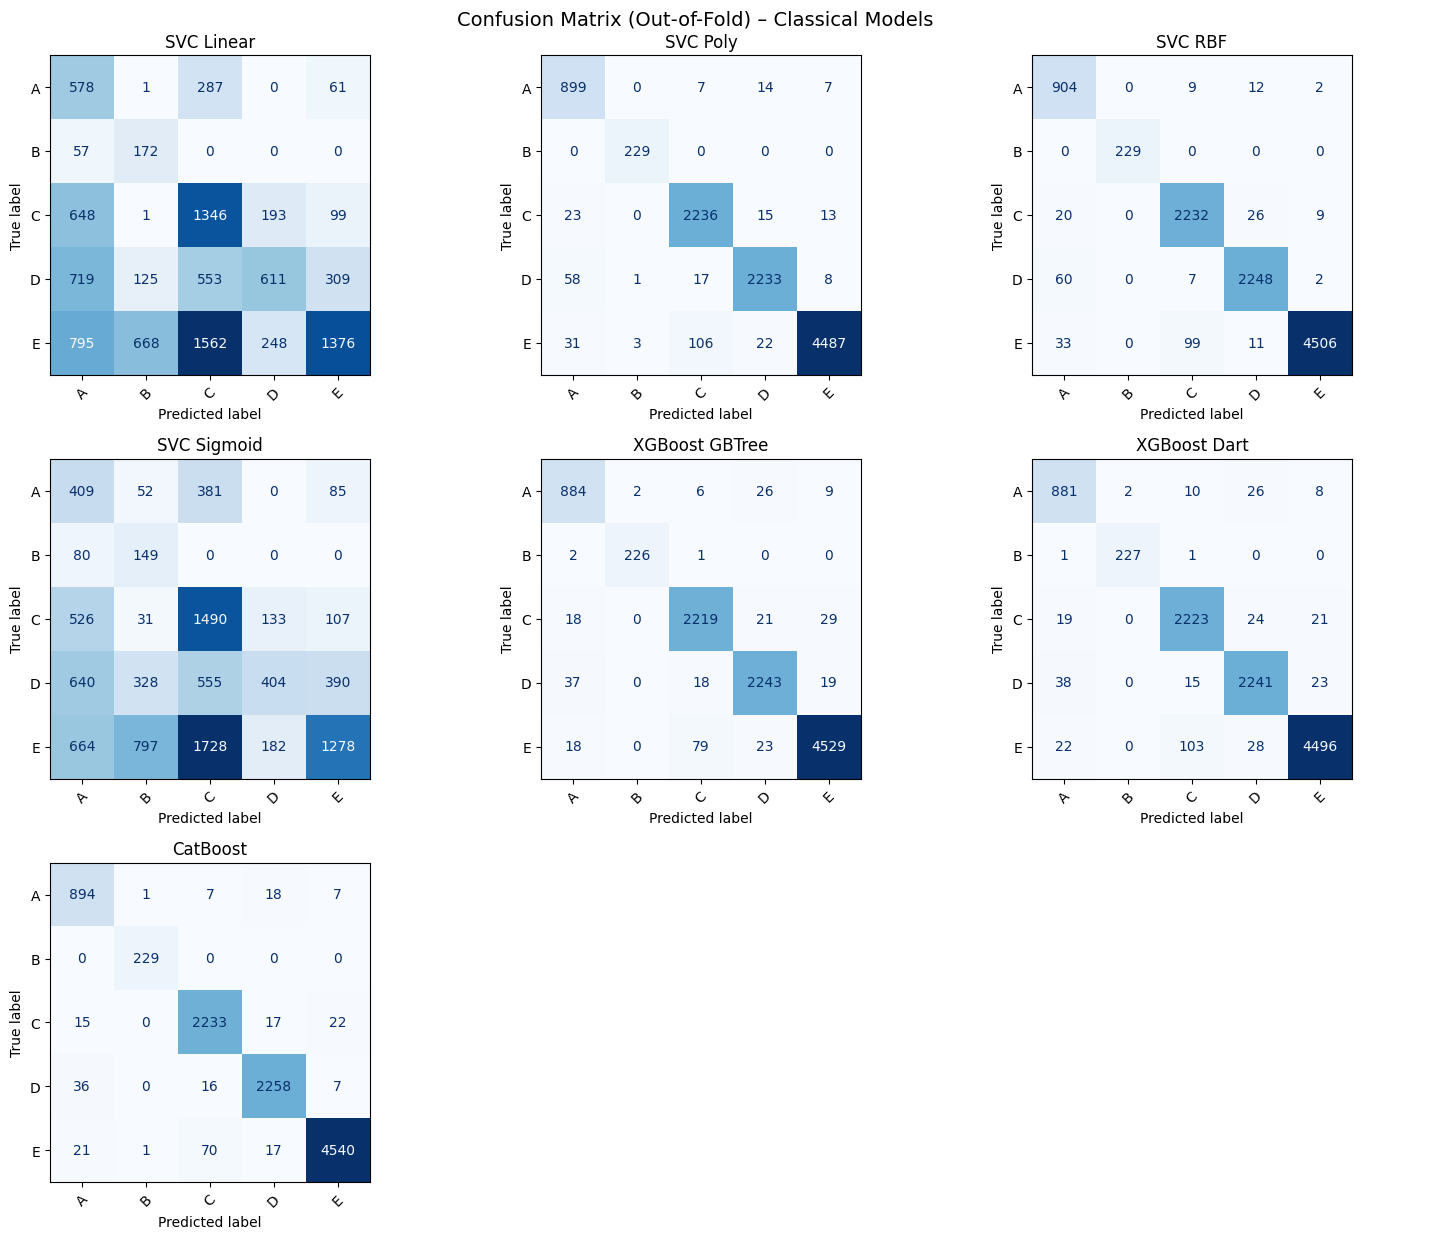

✅ Saved: ./results/confusion_matrix_classical_hpo.png
SVC Linear
              precision    recall  f1-score   support

           A       0.21      0.62      0.31       927
           B       0.18      0.75      0.29       229
           C       0.36      0.59      0.45      2287
           D       0.58      0.26      0.36      2317
           E       0.75      0.30      0.42      4649

    accuracy                           0.39     10409
   macro avg       0.41      0.50      0.37     10409
weighted avg       0.56      0.39      0.40     10409

SVC Poly
              precision    recall  f1-score   support

           A       0.89      0.97      0.93       927
           B       0.98      1.00      0.99       229
           C       0.95      0.98      0.96      2287
           D       0.98      0.96      0.97      2317
           E       0.99      0.97      0.98      4649

    accuracy                           0.97     10409
   macro avg       0.96      0.98      0.97     10409
wei

In [46]:
# ════════════════════════════════════════════════════════════
# 🔢 CONFUSION MATRIX – semua model classical (out-of-fold)
# ════════════════════════════════════════════════════════════
# Memakai prediksi out-of-fold (y_true/y_pred) yang dikumpulkan tiap model
# saat cross-validation → confusion matrix mencerminkan generalisasi, bukan
# performa di data training. Berguna untuk melihat kelas minoritas (mis. B).
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

class_names = list(label_encoder.classes_)
labels = np.arange(len(class_names))

models_cm = [r for r in all_best if "y_true" in r and "y_pred" in r]
if not models_cm:
    print("⚠️  Belum ada y_true/y_pred di all_best. Jalankan ulang sel-sel training dulu.")
else:
    n = len(models_cm)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.2 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, r in zip(axes, models_cm):
        cm = confusion_matrix(r["y_true"], r["y_pred"], labels=labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
        ax.set_title(r["model"])
        ax.tick_params(axis="x", rotation=45)

    for ax in axes[len(models_cm):]:
        ax.axis("off")

    fig.suptitle("Confusion Matrix (Out-of-Fold) – Classical Models", fontsize=14)
    fig.tight_layout()

    os.makedirs("./results", exist_ok=True)
    out_path = "./results/confusion_matrix_classical_hpo.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {out_path}")

    # ── Classification report per model (lihat performa per kelas) ──
    for r in models_cm:
        print("" + "=" * 60)
        print(r["model"])
        print("=" * 60)
        print(classification_report(
            r["y_true"], r["y_pred"],
            labels=labels, target_names=class_names, zero_division=0,
        ))


---
## 🧾 Classification Report per Kelas (semua model)

Precision / Recall / F1-score / Support **per kelas** untuk tiap model, dari prediksi *out-of-fold* (`y_true`/`y_pred`). Fokuskan ke recall kelas minoritas (mis. **B**) untuk menilai efek `class_weight='balanced'`. Baris `accuracy`/`macro avg`/`weighted avg` adalah ringkasan global.

In [47]:
# ════════════════════════════════════════════════════════════
# 🧾 CLASSIFICATION REPORT (tabel) – per kelas, tiap model
# ════════════════════════════════════════════════════════════
# classification_report(output_dict=True) -> DataFrame agar rapi & bisa disimpan.
import os
import pandas as pd
from sklearn.metrics import classification_report, f1_score

os.makedirs('./results', exist_ok=True)
models_cr = [r for r in all_best if 'y_true' in r and 'y_pred' in r]

per_class_f1 = {}   # untuk tabel perbandingan antar-model
for r in models_cr:
    rep = classification_report(
        r['y_true'], r['y_pred'], labels=labels,
        target_names=class_names, zero_division=0, output_dict=True)
    cr_df = pd.DataFrame(rep).T
    cr_df['support'] = cr_df['support'].astype(int)
    print('=' * 60)
    print(r['model'])
    print('=' * 60)
    display(cr_df.style.format({'precision': '{:.4f}', 'recall': '{:.4f}',
                                'f1-score': '{:.4f}', 'support': '{:.0f}'}))
    fname = f"./results/classification_report_{r['model'].replace(' ', '_').lower()}.csv"
    cr_df.to_csv(fname)
    per_class_f1[r['model']] = [f1_score(r['y_true'], r['y_pred'], labels=[c],
                                         average='macro', zero_division=0)
                                for c in labels]

# ── Perbandingan F1 per kelas antar model (baris = kelas, kolom = model) ──
f1_compare = pd.DataFrame(per_class_f1, index=class_names)
f1_compare.index.name = 'Kelas'
f1_compare.to_csv('./results/per_class_f1_compare.csv')
print()
print('F1-score per kelas — perbandingan antar model:')
display(f1_compare.style.format('{:.4f}')
        .background_gradient(cmap='RdYlGn', axis=None))
print('✅ Saved: ./results/classification_report_<model>.csv & per_class_f1_compare.csv')

SVC Linear


,precision,recall,f1-score,support
A,0.2066,0.6235,0.3104,927
B,0.1779,0.7511,0.2876,229
C,0.3591,0.5885,0.4461,2287
D,0.5808,0.2637,0.3627,2317
E,0.7458,0.2960,0.4238,4649
accuracy,0.3923,0.3923,0.3923,0
macro avg,0.4140,0.5046,0.3661,10409
weighted avg,0.5636,0.3923,0.4020,10409


SVC Poly


,precision,recall,f1-score,support
A,0.8892,0.9698,0.9278,927
B,0.9828,1.0000,0.9913,229
C,0.9451,0.9777,0.9611,2287
D,0.9777,0.9637,0.9707,2317
E,0.9938,0.9652,0.9793,4649
accuracy,0.9688,0.9688,0.9688,0
macro avg,0.9577,0.9753,0.9660,10409
weighted avg,0.9699,0.9688,0.9690,10409


SVC RBF


...

CatBoost


,precision,recall,f1-score,support
A,0.9255,0.9644,0.9445,927
B,0.9913,1.0000,0.9957,229
C,0.9600,0.9764,0.9681,2287
D,0.9775,0.9745,0.9760,2317
E,0.9921,0.9766,0.9843,4649
accuracy,0.9755,0.9755,0.9755,0
macro avg,0.9693,0.9784,0.9737,10409
weighted avg,0.9759,0.9755,0.9756,10409



F1-score per kelas — perbandingan antar model:


,SVC Linear,SVC Poly,SVC RBF,SVC Sigmoid,XGBoost GBTree,XGBoost Dart,CatBoost
Kelas,,,,,,,
A,0.3104,0.9278,0.9300,0.2520,0.9374,0.9333,0.9445
B,0.2876,0.9913,1.0000,0.1879,0.9891,0.9913,0.9957
C,0.4461,0.9611,0.9633,0.4627,0.9627,0.9584,0.9681
D,0.3627,0.9707,0.9744,0.2661,0.9689,0.9668,0.9760
E,0.4238,0.9793,0.9830,0.3927,0.9808,0.9777,0.9843


✅ Saved: ./results/classification_report_<model>.csv & per_class_f1_compare.csv


CatBoost terakhir dengan waktu eksekusi 168.8900 merupakan `loss_function="Multiclass"`, sedangkan dua sisanya adalah `loss_function="MulticlassOneVsAll"`

In [48]:
import os
os.makedirs('./results', exist_ok=True)
eval_df.to_csv('./results/eval_classical_final_hpo.csv', index=True)
print('✅ Saved: ./results/eval_classical_final_hpo.csv')

✅ Saved: ./results/eval_classical_final_hpo.csv


---
## 📈 Kurva per Model — Macro-F1 & Loss Function

Untuk **tiap model** (semua pakai `class_weight='balanced'`) ditampilkan learning curve train vs validasi dengan dua metrik: **Macro-F1** (↑ makin baik, tahan terhadap imbalance) dan **Log Loss** (loss function / cross-entropy, ↓ makin baik).

In [49]:
# ════════════════════════════════════════════════════════════
# 📈 Learning Curve — semua model classical (balanced)
#     Dua metrik per model: Macro-F1 (↑ makin baik) & Log Loss (↓ makin baik)
# ════════════════════════════════════════════════════════════
# Untuk tiap model best, hitung kurva train vs val pada beberapa ukuran
# training set, dengan DUA scoring:
#   - Macro-F1 : rata-rata F1 antar kelas (tidak bias ke kelas mayoritas →
#                cocok untuk data imbalance).
#   - Log Loss : loss function (cross-entropy) untuk cek overfit/underfit.
#
# CATATAN PERFORMA:
#   - Default pakai seluruh data (LC_N = len(X)). Turunkan LC_N untuk lebih cepat.
#   - SVC dengan training >5000 sampel akan sangat lambat (O(N²)).

import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import learning_curve, StratifiedShuffleSplit, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ── Konfigurasi ───────────────────────────────────────────────────────────────
LC_N           = len(X)                                  # subsample (stratified)
LC_TRAIN_SIZES = np.linspace(0.2, 1.0, 5)                # 5 titik kurva
LC_CV          = 5                                       # CV folds (StratifiedKFold shuffle=True, sama dengan training)
LC_STATE       = 42
LC_BASELINE    = float(np.log(len(np.unique(y))))        # log loss tebakan-acak (ambang verdict loss)


# ── Wrapper XGBoost agar otomatis compute sample_weight per .fit() ────────────
class XGBBalancedWrapper(ClassifierMixin, BaseEstimator):
    """XGBClassifier yang otomatis pakai class_weight='balanced' analog SVC."""
    def __init__(self, **xgb_params):
        self.xgb_params = xgb_params

    def get_params(self, deep=True):
        return dict(self.xgb_params)

    def set_params(self, **params):
        self.xgb_params.update(params)
        return self

    def fit(self, X, y, sample_weight=None):
        self.model_ = XGBClassifier(device='cuda', **self.xgb_params)
        sw = compute_sample_weight("balanced", y) if sample_weight is None else sample_weight
        self.model_.fit(X, y, sample_weight=sw)
        self.classes_ = self.model_.classes_
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


# ── Factory: rekonstruksi pipeline dari (model_name, best_params) ────────────
#    Semua classifier memakai bobot kelas 'balanced' (class_weight /
#    sample_weight / auto_class_weights) — konsisten dengan training di atas.
def make_classical(model_name, params):
    base = [
        ("scaler", StandardScaler()),
        ("pca",    PCA(n_components=n_optimal)),
    ]
    if   model_name == "SVC Linear":
        clf = SVC(kernel="linear",  probability=True, random_state=42,
                  decision_function_shape="ovr", class_weight='balanced', **params)
    elif model_name == "SVC Poly":
        clf = SVC(kernel="poly",    probability=True, random_state=42,
                  decision_function_shape="ovr", class_weight='balanced', **params)
    elif model_name == "SVC RBF":
        clf = SVC(kernel="rbf",     probability=True, random_state=42,
                  decision_function_shape="ovr", class_weight='balanced', **params)
    elif model_name == "SVC Sigmoid":
        clf = SVC(kernel="sigmoid", probability=True, random_state=42,
                  decision_function_shape="ovr", class_weight='balanced', **params)
    elif model_name == "XGBoost GBTree":
        clf = XGBBalancedWrapper(booster="gbtree", objective="multi:softprob",
                                 random_state=42, **params)
    elif model_name == "XGBoost Dart":
        clf = XGBBalancedWrapper(booster="dart",  objective="multi:softprob",
                                 random_state=42, **params)
    elif model_name == "CatBoost":
        clf = CatBoostClassifier(
            loss_function="MultiClassOneVsAll",
            eval_metric="Accuracy",
            verbose=0,
            random_seed=42,
            auto_class_weights="Balanced",
            task_type="GPU",
            **params,
        )
    else:
        raise ValueError(f"Unknown model_name: {model_name}")
    base.append(("clf", clf))
    return Pipeline(base)


# ── Stratified subsample untuk speed ──────────────────────────────────────────
if LC_N < len(X):
    sss = StratifiedShuffleSplit(n_splits=1, train_size=LC_N, random_state=LC_STATE)
    sub_idx, _ = next(sss.split(X, y))
    X_lc, y_lc = X.iloc[sub_idx], y[sub_idx]
else:
    X_lc, y_lc = X, y
print(f"📊 Learning curve on N={len(X_lc)} samples | CV={LC_CV} | sizes={LC_TRAIN_SIZES}")

# ── Hitung learning curve per model untuk DUA metrik (macro-F1 & log loss) ────
_lc_common = dict(
    train_sizes=LC_TRAIN_SIZES,
    cv=StratifiedKFold(n_splits=LC_CV, shuffle=True, random_state=LC_STATE),
    n_jobs=1, shuffle=True, random_state=LC_STATE, error_score='raise',
)
lc_results = []
for entry in all_best:
    name   = entry["model"]
    params = entry.get("params", {})
    print(f"\n  ▶ {name}  ({params}) ...", end=" ", flush=True)
    try:
        pipe = make_classical(name, params)
        # Macro-F1 (makin besar makin baik)
        ts, f1_tr, f1_va = learning_curve(
            pipe, X_lc, y_lc, scoring="f1_macro", **_lc_common)
        # Log loss / cross-entropy (neg_log_loss → dibalik ke positif; makin kecil makin baik)
        _,  ll_tr, ll_va = learning_curve(
            pipe, X_lc, y_lc, scoring="neg_log_loss", **_lc_common)
        ll_tr, ll_va = -ll_tr, -ll_va
        lc_results.append({
            "model":       name,
            "params":      params,
            "train_sizes": ts,
            "f1_train_mean": f1_tr.mean(axis=1), "f1_train_std": f1_tr.std(axis=1),
            "f1_val_mean":   f1_va.mean(axis=1), "f1_val_std":   f1_va.std(axis=1),
            "loss_train_mean": ll_tr.mean(axis=1), "loss_train_std": ll_tr.std(axis=1),
            "loss_val_mean":   ll_va.mean(axis=1), "loss_val_std":   ll_va.std(axis=1),
        })
        print("done")
    except Exception as e:
        print(f"FAILED — {type(e).__name__}: {e}")


# ── Helper plot grid satu metrik ──────────────────────────────────────────────
def _plot_lc_grid(metric, ylabel, lower_is_better, verdict_fn, fname, suptitle):
    n_models = len(lc_results)
    ncols    = 3
    nrows    = (n_models + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5.5 * ncols, 4 * nrows),
                             constrained_layout=True)
    axes = np.array(axes).flatten()
    for ax, r in zip(axes, lc_results):
        ts   = r["train_sizes"]
        trm, trs = r[f"{metric}_train_mean"], r[f"{metric}_train_std"]
        vam, vas = r[f"{metric}_val_mean"],   r[f"{metric}_val_std"]
        ax.plot(ts, trm, "o-", color="steelblue",  linewidth=2, label="Train")
        ax.fill_between(ts, trm - trs, trm + trs, alpha=0.2, color="steelblue")
        ax.plot(ts, vam, "s-", color="darkorange", linewidth=2, label="Val")
        ax.fill_between(ts, vam - vas, vam + vas, alpha=0.2, color="darkorange")
        gap, verdict = verdict_fn(trm, vam)
        ax.set_title(f"{r['model']}\ngap={gap:+.3f}  |  {verdict}",
                     fontsize=11, fontweight="bold")
        ax.set_xlabel("Training set size")
        ax.set_ylabel(ylabel)
        if lower_is_better:
            ax.set_ylim(bottom=0)
        else:
            ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.4)
        ax.legend(fontsize=8)
    for ax in axes[n_models:]:
        ax.set_visible(False)
    fig.suptitle(suptitle, fontsize=13, fontweight="bold")
    import os
    os.makedirs("./results", exist_ok=True)
    fig.savefig(fname, dpi=120, bbox_inches="tight")
    print(f"📊 Plot disimpan → {fname}")
    plt.show()


# ── Verdict per metrik (gap train↔val di ukuran training terbesar) ───────────
def _verdict_f1(trm, vam):
    gap = trm[-1] - vam[-1]                # train_f1 − val_f1 (>0 → overfit)
    if   gap > 0.15:                          v = "⚠️ OVERFIT"
    elif vam[-1] < 0.50:                      v = "⚠️ UNDERFIT"
    elif gap < 0.05 and vam[-1] > 0.70:       v = "✅ Well-fit"
    else:                                     v = "🟡 Mild gap"
    return gap, v

def _verdict_loss(trm, vam):
    gap = vam[-1] - trm[-1]                # val_loss − train_loss (>0 → overfit)
    if   gap > 0.15 * LC_BASELINE:                                  v = "⚠️ OVERFIT"
    elif vam[-1] > 0.80 * LC_BASELINE:                             v = "⚠️ UNDERFIT"
    elif gap < 0.05 * LC_BASELINE and vam[-1] < 0.40 * LC_BASELINE: v = "✅ Well-fit"
    else:                                                          v = "🟡 Mild gap"
    return gap, v


📊 Learning curve on N=10409 samples | CV=5 | sizes=[0.2 0.4 0.6 0.8 1. ]

  ▶ SVC Linear  ({'C': 10, 'tol': 0.1}) ... done

  ▶ SVC Poly  ({'C': 1, 'tol': 0.1, 'degree': 5, 'gamma': 0.5, 'coef0': 3}) ... done

  ▶ SVC RBF  ({'C': 10, 'tol': 0.1, 'gamma': 0.5}) ... done

  ▶ SVC Sigmoid  ({'C': 1, 'tol': 0.1, 'gamma': 0.01, 'coef0': 0}) ... done

  ▶ XGBoost GBTree  ({'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 10}) ... done

  ▶ XGBoost Dart  ({'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 10, 'rate_drop': 0.1, 'skip_drop': 0.5}) ... done

  ▶ CatBoost  ({'iterations': 500, 'depth': 10, 'learning_rate': 0.1, 'l2_leaf_reg': 1}) ... done


📊 Plot disimpan → ./results/learning_curve_classical_balanced_hpo_macrof1.png


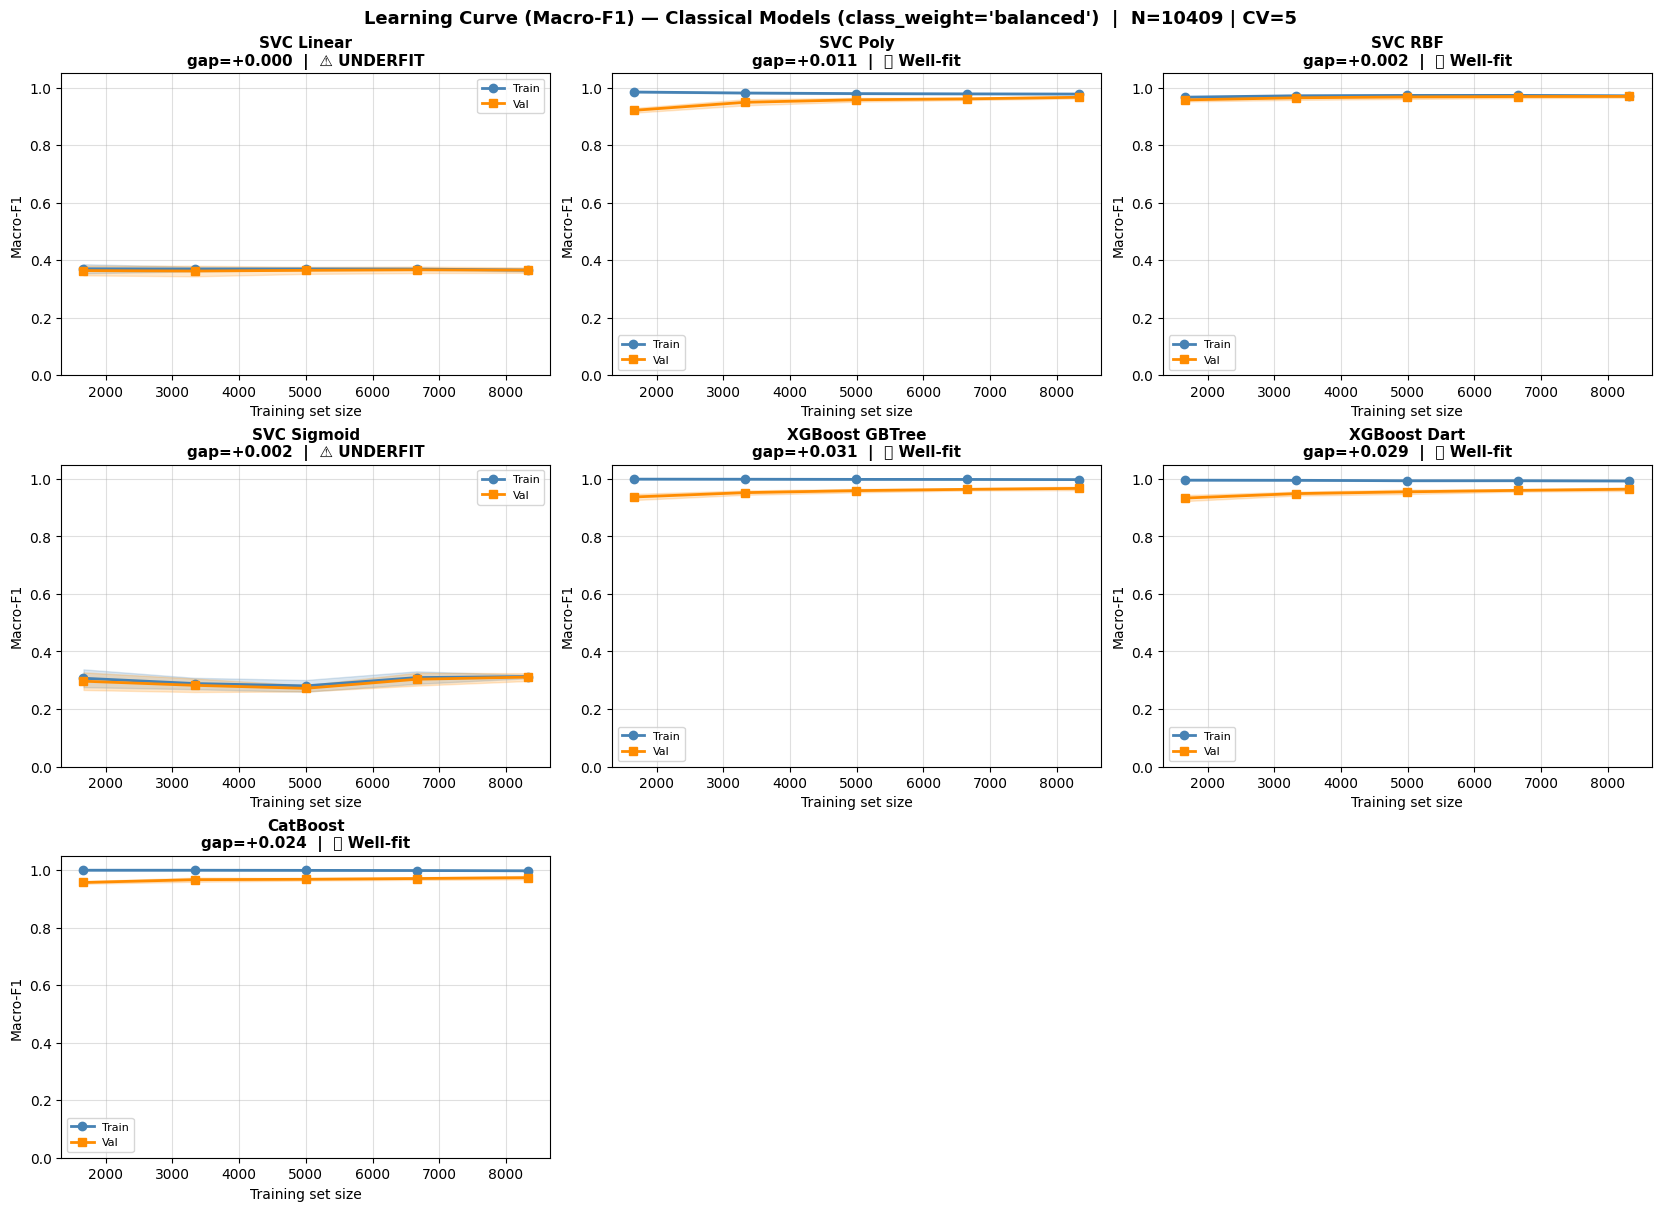

📊 Plot disimpan → ./results/learning_curve_classical_balanced_hpo_logloss.png


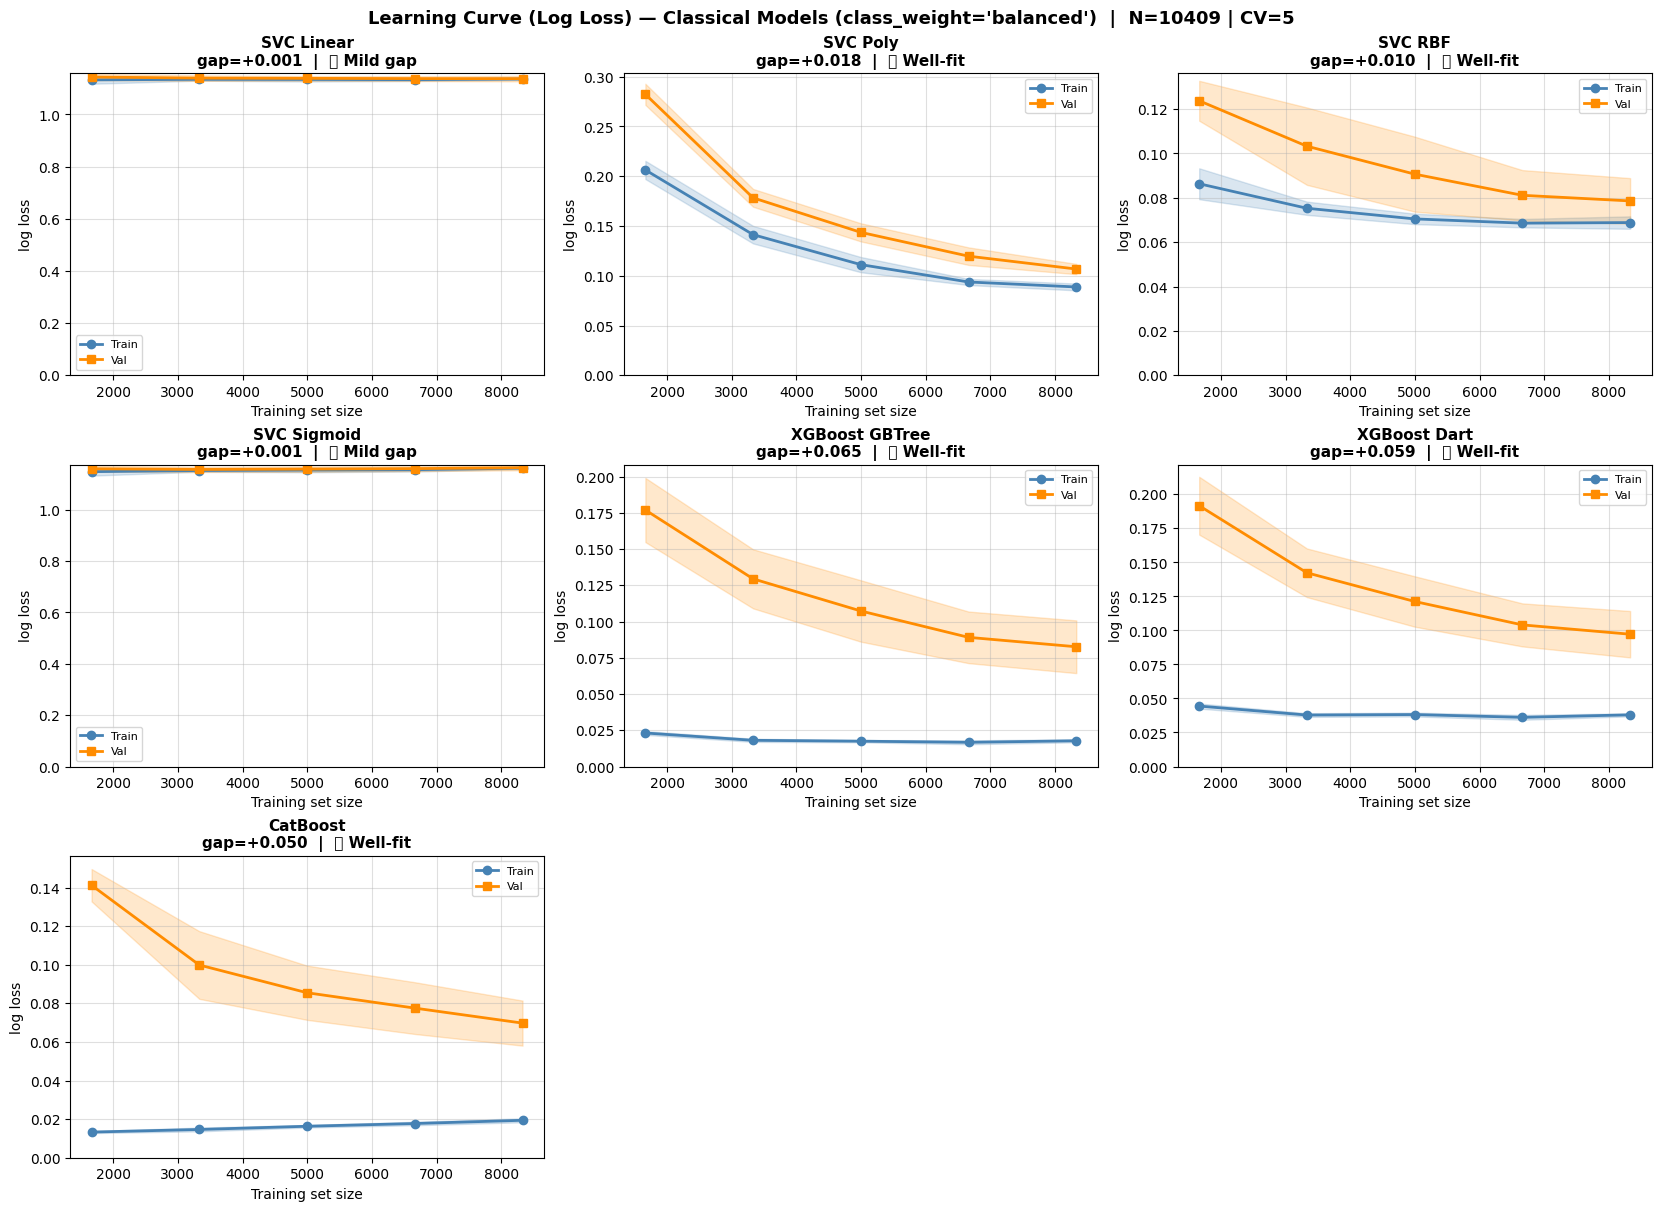


──── Ringkasan akhir (training size terbesar) ────
Model                  TrainF1     ValF1    F1Gap  TrainLoss    ValLoss  LossGap
CatBoost                0.9980    0.9741  +0.0239     0.0194     0.0697  +0.0504
SVC RBF                 0.9721    0.9700  +0.0020     0.0688     0.0786  +0.0098
XGBoost GBTree          0.9978    0.9673  +0.0305     0.0177     0.0826  +0.0649
SVC Poly                0.9782    0.9670  +0.0112     0.0887     0.1068  +0.0180
XGBoost Dart            0.9930    0.9645  +0.0285     0.0380     0.0972  +0.0592
SVC Linear              0.3660    0.3658  +0.0002     1.1361     1.1374  +0.0013
SVC Sigmoid             0.3128    0.3110  +0.0018     1.1614     1.1628  +0.0015


In [50]:
# ── Grid 1: Macro-F1 ────────────────
_plot_lc_grid(
    "f1", "Macro-F1", lower_is_better=False, verdict_fn=_verdict_f1,
    fname="./results/learning_curve_classical_balanced_hpo_macrof1.png",
    suptitle=(f"Learning Curve (Macro-F1) — Classical Models (class_weight='balanced')  |  "
              f"N={len(X_lc)} | CV={LC_CV}"),
)

# ── Grid 2: Log Loss (loss function) ──────────
_plot_lc_grid(
    "loss", "log loss", lower_is_better=True, verdict_fn=_verdict_loss,
    fname="./results/learning_curve_classical_balanced_hpo_logloss.png",
    suptitle=(f"Learning Curve (Log Loss) — Classical Models (class_weight='balanced')  |  "
              f"N={len(X_lc)} | CV={LC_CV}"),
)

# ── Ringkasan tekstual (training size terbesar) ──────
# F1Gap  = Train−Val (>0 → overfit); LossGap = Val−Train (>0 → overfit).
print("\n──── Ringkasan akhir (training size terbesar) ────")
print(f"{'Model':<20s} {'TrainF1':>9s} {'ValF1':>9s} {'F1Gap':>8s} "
      f"{'TrainLoss':>10s} {'ValLoss':>10s} {'LossGap':>8s}")
for r in sorted(lc_results, key=lambda x: -x["f1_val_mean"][-1]):
    f1_gap   = r["f1_train_mean"][-1] - r["f1_val_mean"][-1]
    loss_gap = r["loss_val_mean"][-1] - r["loss_train_mean"][-1]
    print(f"{r['model']:<20s} "
          f"{r['f1_train_mean'][-1]:>9.4f} {r['f1_val_mean'][-1]:>9.4f} {f1_gap:>+8.4f} "
          f"{r['loss_train_mean'][-1]:>10.4f} {r['loss_val_mean'][-1]:>10.4f} {loss_gap:>+8.4f}")